# Day 4 — Performance Analytics
## Capstone Project I — Mutual Fund Analytics

**What we compute today:**
1. Daily Returns for all 40 funds
2. CAGR — 1yr, 3yr, 5yr
3. Sharpe Ratio (risk-adjusted return)
4. Sortino Ratio (downside risk only)
5. Alpha and Beta (vs Nifty 100)
6. Maximum Drawdown (worst loss from peak)
7. Fund Scorecard (0–100 composite score)
8. Benchmark Comparison Chart

**Deliverables:** `fund_scorecard.csv` · `alpha_beta.csv` · `benchmark_comparison.png`

---
## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, probplot
import warnings
import os

warnings.filterwarnings('ignore')

print('Libraries loaded OK')

Libraries loaded OK


---
## Cell 2 — Load Data

In [2]:
PROC    = os.path.join('..', 'data', 'processed')
REPORTS = os.path.join('..', 'reports')
os.makedirs(REPORTS, exist_ok=True)

nav_df   = pd.read_csv(os.path.join(PROC, '02_nav_history_cleaned.csv'),       parse_dates=['date'])
fund_df  = pd.read_csv(os.path.join(PROC, '01_fund_master_cleaned.csv'))
bench_df = pd.read_csv(os.path.join(PROC, '10_benchmark_indices_cleaned.csv'),  parse_dates=['date'])

nav_df = nav_df.sort_values(['amfi_code', 'date']).reset_index(drop=True)

nav_df = nav_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct']],
    on='amfi_code', how='left'
)

print('NAV rows     :', len(nav_df))
print('Total funds  :', nav_df['amfi_code'].nunique())
print('Date range   :', nav_df['date'].min().date(), 'to', nav_df['date'].max().date())

NAV rows     : 64320
Total funds  : 40
Date range   : 2022-01-03 to 2026-05-29


---
## Task 1 — Daily Returns

**Formula:** `daily_return = (NAV today / NAV yesterday) − 1`

This shows how much a fund went up or down each day in percentage.

In [3]:
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

ret_df = nav_df.dropna(subset=['daily_return']).copy()
ret_df = ret_df[ret_df['daily_return'].abs() < 0.5].copy()

print('Daily return statistics (all funds):')
print(ret_df['daily_return'].describe().round(6))

Daily return statistics (all funds):
count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64


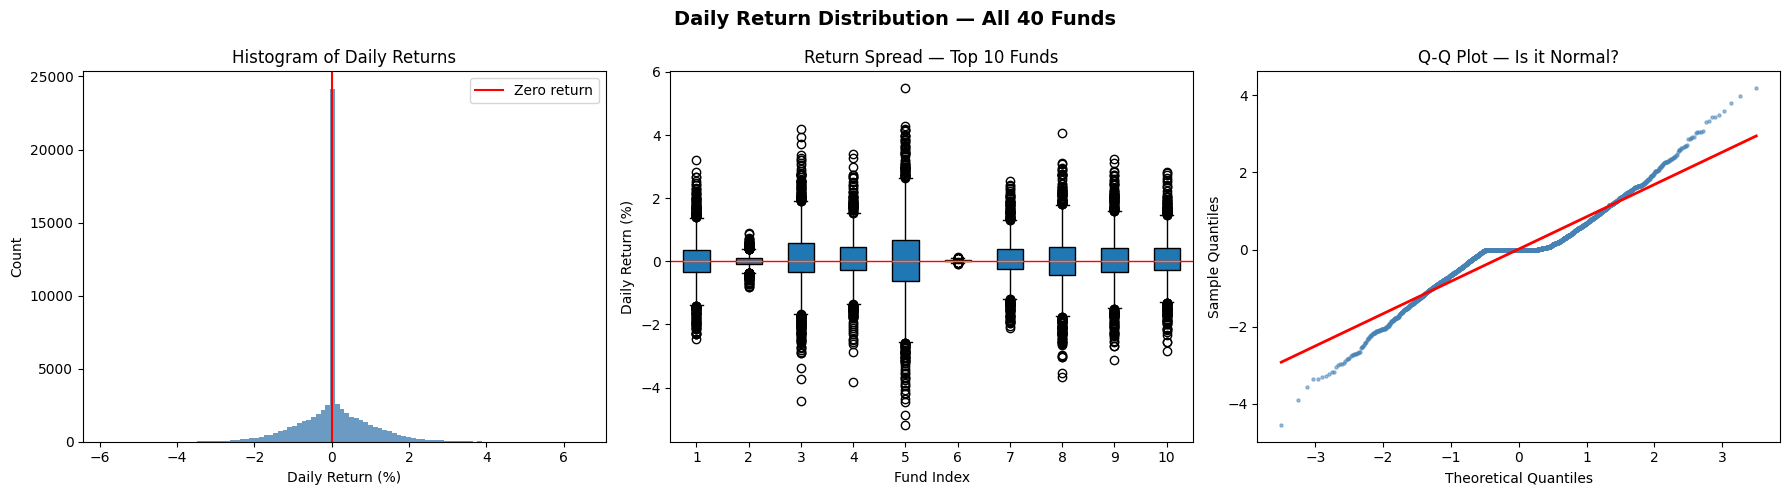

Mean daily return : 0.0451 %
Std deviation     : 0.8706 %
Chart saved: daily_return_distribution.png


In [4]:
all_pct = ret_df['daily_return'] * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Daily Return Distribution — All 40 Funds', fontsize=14, fontweight='bold')

axes[0].hist(all_pct, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(0, color='red', linewidth=1.5, label='Zero return')
axes[0].set_title('Histogram of Daily Returns')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Count')
axes[0].legend()

top10_codes = ret_df['amfi_code'].value_counts().head(10).index.tolist()
box_data = [ret_df[ret_df['amfi_code'] == c]['daily_return'].values * 100 for c in top10_codes]
axes[1].boxplot(box_data, patch_artist=True)
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_title('Return Spread — Top 10 Funds')
axes[1].set_xlabel('Fund Index')
axes[1].set_ylabel('Daily Return (%)')

sample = all_pct.dropna().sample(min(3000, len(all_pct)), random_state=42)
(osm, osr), (slope, intercept, _) = probplot(sample, dist='norm')
axes[2].scatter(osm, osr, s=5, alpha=0.5, color='steelblue')
axes[2].plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=2)
axes[2].set_title('Q-Q Plot — Is it Normal?')
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'daily_return_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Mean daily return :', round(all_pct.mean(), 4), '%')
print('Std deviation     :', round(all_pct.std(), 4), '%')
print('Chart saved: daily_return_distribution.png')

---
## Task 2 — CAGR (Compound Annual Growth Rate)

**Formula:** `CAGR = (NAV at end ÷ NAV at start) ^ (1 ÷ years) − 1`

This tells us the average yearly growth of a fund.

In [5]:
def get_cagr(nav_series, date_series, years):
    end_date   = date_series.max()
    start_date = end_date - pd.DateOffset(years=years)

    end_rows   = nav_series[date_series >= end_date - pd.Timedelta(days=5)]
    start_rows = nav_series[
        (date_series >= start_date - pd.Timedelta(days=5)) &
        (date_series <= start_date + pd.Timedelta(days=10))
    ]

    if end_rows.empty or start_rows.empty:
        return np.nan

    nav_end   = end_rows.iloc[-1]
    nav_start = start_rows.iloc[0]

    if nav_start <= 0:
        return np.nan

    return (nav_end / nav_start) ** (1 / years) - 1


cagr_list = []

for code, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date')
    cagr_list.append({
        'amfi_code'  : code,
        'scheme_name': group['scheme_name'].iloc[0],
        'fund_house' : group['fund_house'].iloc[0],
        'category'   : group['category'].iloc[0],
        'cagr_1yr'   : get_cagr(group['nav'], group['date'], 1),
        'cagr_3yr'   : get_cagr(group['nav'], group['date'], 3),
        'cagr_5yr'   : get_cagr(group['nav'], group['date'], 5),
    })

cagr_df = pd.DataFrame(cagr_list)
cagr_df = cagr_df.sort_values('cagr_3yr', ascending=False).reset_index(drop=True)
cagr_df['cagr_rank_3yr'] = range(1, len(cagr_df) + 1)

print('Top 10 Funds by 3-Year CAGR:')
print()
for _, row in cagr_df.head(10).iterrows():
    c1 = f"{row['cagr_1yr']*100:.2f}%" if pd.notna(row['cagr_1yr']) else 'N/A'
    c3 = f"{row['cagr_3yr']*100:.2f}%" if pd.notna(row['cagr_3yr']) else 'N/A'
    c5 = f"{row['cagr_5yr']*100:.2f}%" if pd.notna(row['cagr_5yr']) else 'N/A'
    print(f"  Rank {int(row['cagr_rank_3yr']):<3}  {row['scheme_name'][:45]:<45}  1yr:{c1}  3yr:{c3}  5yr:{c5}")

Top 10 Funds by 3-Year CAGR:

  Rank 1    Axis Midcap Fund - Regular - Growth            1yr:24.66%  3yr:35.89%  5yr:N/A
  Rank 2    Mirae Asset Large Cap Fund - Regular - Growth  1yr:23.24%  3yr:34.77%  5yr:N/A
  Rank 3    ICICI Pru Bluechip Fund - Direct - Growth      1yr:13.09%  3yr:32.54%  5yr:N/A
  Rank 4    HDFC Mid-Cap Opportunities Fund - Regular - G  1yr:56.77%  3yr:32.52%  5yr:N/A
  Rank 5    ICICI Pru Midcap Fund - Regular - Growth       1yr:31.09%  3yr:32.29%  5yr:N/A
  Rank 6    SBI Bluechip Fund - Regular Plan - Growth      1yr:64.59%  3yr:30.79%  5yr:N/A
  Rank 7    Mirae Asset Tax Saver Fund - Regular - Growth  1yr:39.09%  3yr:28.85%  5yr:N/A
  Rank 8    Kotak Flexicap Fund - Regular - Growth         1yr:23.57%  3yr:28.81%  5yr:N/A
  Rank 9    ABSL Frontline Equity Fund - Regular - Growth  1yr:46.40%  3yr:27.91%  5yr:N/A
  Rank 10   DSP Small Cap Fund - Regular - Growth          1yr:65.61%  3yr:27.85%  5yr:N/A


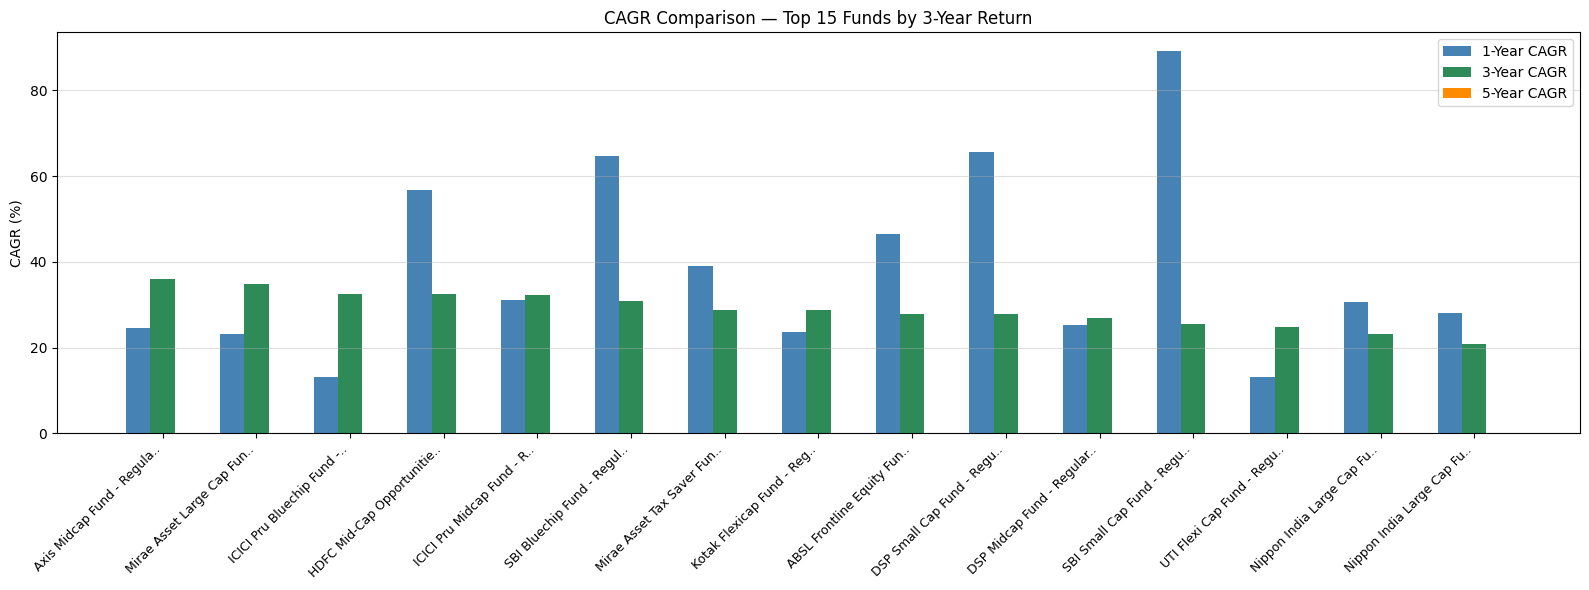

Chart saved: cagr_comparison.png


In [6]:
top15 = cagr_df.head(15).copy()
names = [n[:25] + '..' if len(n) > 25 else n for n in top15['scheme_name']]
x = np.arange(len(top15))
w = 0.26

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w, top15['cagr_1yr'].fillna(0) * 100, w, label='1-Year CAGR', color='steelblue')
ax.bar(x,     top15['cagr_3yr'].fillna(0) * 100, w, label='3-Year CAGR', color='seagreen')
ax.bar(x + w, top15['cagr_5yr'].fillna(0) * 100, w, label='5-Year CAGR', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('CAGR (%)')
ax.set_title('CAGR Comparison — Top 15 Funds by 3-Year Return')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'cagr_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: cagr_comparison.png')

---
## Task 3 — Sharpe Ratio

**Formula:** `Sharpe = (Mean Return − Risk-Free Rate) / Std Dev × √252`

- Risk-free rate = **6.5% per year** (RBI repo rate)
- Higher Sharpe = better return for the risk you are taking
- Sharpe > 1.0 is considered **excellent**

In [7]:
RF_DAILY = 0.065 / 252

sharpe_list = []

for code, group in ret_df.groupby('amfi_code'):
    returns  = group['daily_return'].dropna()
    mean_ret = returns.mean()
    std_ret  = returns.std()

    if len(returns) < 100 or std_ret == 0:
        continue

    sharpe_list.append({
        'amfi_code'    : code,
        'scheme_name'  : group['scheme_name'].iloc[0],
        'category'     : group['category'].iloc[0],
        'annual_return': mean_ret * 252,
        'annual_std'   : std_ret * np.sqrt(252),
        'sharpe_ratio' : (mean_ret - RF_DAILY) / std_ret * np.sqrt(252),
    })

sharpe_df = pd.DataFrame(sharpe_list).sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['sharpe_rank'] = range(1, len(sharpe_df) + 1)

print('Top 10 Funds by Sharpe Ratio:')
print()
for _, row in sharpe_df.head(10).iterrows():
    print(f"  Rank {int(row['sharpe_rank']):<3}  {row['scheme_name'][:48]:<48}  Sharpe: {row['sharpe_ratio']:.3f}")

Top 10 Funds by Sharpe Ratio:

  Rank 1    Mirae Asset Large Cap Fund - Regular - Growth     Sharpe: 1.068
  Rank 2    Kotak Flexicap Fund - Regular - Growth            Sharpe: 0.966
  Rank 3    Mirae Asset Tax Saver Fund - Regular - Growth     Sharpe: 0.919
  Rank 4    ICICI Pru Midcap Fund - Regular - Growth          Sharpe: 0.883
  Rank 5    SBI Bluechip Fund - Regular Plan - Growth         Sharpe: 0.861
  Rank 6    DSP Midcap Fund - Regular - Growth                Sharpe: 0.833
  Rank 7    HDFC Mid-Cap Opportunities Fund - Regular - Grow  Sharpe: 0.808
  Rank 8    Nippon India Large Cap Fund - Regular - Growth    Sharpe: 0.759
  Rank 9    Axis Midcap Fund - Regular - Growth               Sharpe: 0.731
  Rank 10   ABSL Frontline Equity Fund - Regular - Growth     Sharpe: 0.717


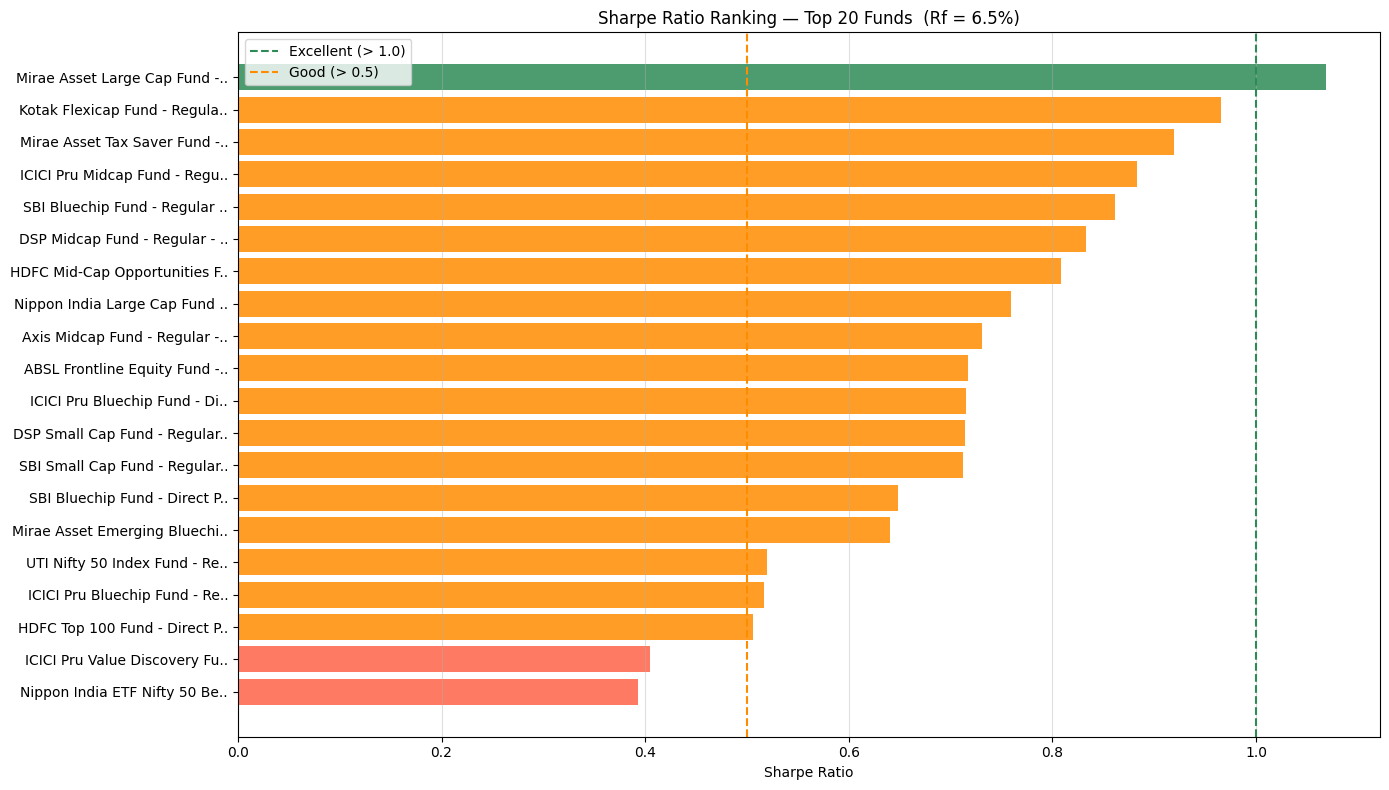

Chart saved: sharpe_ratio_ranking.png


In [8]:
top20 = sharpe_df.head(20).copy()
names = [n[:28] + '..' if len(n) > 28 else n for n in top20['scheme_name']]
colors = ['seagreen' if s > 1 else 'darkorange' if s > 0.5 else 'tomato'
          for s in top20['sharpe_ratio']]

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(names[::-1], top20['sharpe_ratio'].values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(1.0, color='seagreen',   linestyle='--', linewidth=1.5, label='Excellent (> 1.0)')
ax.axvline(0.5, color='darkorange', linestyle='--', linewidth=1.5, label='Good (> 0.5)')
ax.set_xlabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio Ranking — Top 20 Funds  (Rf = 6.5%)')
ax.legend()
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'sharpe_ratio_ranking.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: sharpe_ratio_ranking.png')

---
## Task 4 — Sortino Ratio

**Formula:** `Sortino = (Mean Return − Risk-Free Rate) / Downside Std × √252`

Same as Sharpe, but the denominator only uses **negative return days**.
It penalises funds that have big losses on bad days.

In [9]:
sortino_list = []

for code, group in ret_df.groupby('amfi_code'):
    returns     = group['daily_return'].dropna()
    neg_returns = returns[returns < 0]

    if len(returns) < 100 or len(neg_returns) < 10:
        continue

    mean_ret     = returns.mean()
    downside_std = neg_returns.std()

    if downside_std == 0:
        continue

    sortino_list.append({
        'amfi_code'        : code,
        'scheme_name'      : group['scheme_name'].iloc[0],
        'category'         : group['category'].iloc[0],
        'sortino_ratio'    : (mean_ret - RF_DAILY) / downside_std * np.sqrt(252),
        'downside_std_ann' : downside_std * np.sqrt(252),
        'pct_negative_days': len(neg_returns) / len(returns) * 100,
    })

sortino_df = pd.DataFrame(sortino_list).sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['sortino_rank'] = range(1, len(sortino_df) + 1)

print('Top 10 Funds by Sortino Ratio:')
print()
for _, row in sortino_df.head(10).iterrows():
    print(f"  Rank {int(row['sortino_rank']):<3}  {row['scheme_name'][:48]:<48}  Sortino: {row['sortino_ratio']:.3f}")

Top 10 Funds by Sortino Ratio:

  Rank 1    Mirae Asset Large Cap Fund - Regular - Growth     Sortino: 1.491
  Rank 2    Kotak Flexicap Fund - Regular - Growth            Sortino: 1.480
  Rank 3    Mirae Asset Tax Saver Fund - Regular - Growth     Sortino: 1.353
  Rank 4    SBI Bluechip Fund - Regular Plan - Growth         Sortino: 1.291
  Rank 5    ICICI Pru Midcap Fund - Regular - Growth          Sortino: 1.286
  Rank 6    DSP Midcap Fund - Regular - Growth                Sortino: 1.168
  Rank 7    HDFC Mid-Cap Opportunities Fund - Regular - Grow  Sortino: 1.144
  Rank 8    Nippon India Large Cap Fund - Regular - Growth    Sortino: 1.099
  Rank 9    SBI Small Cap Fund - Regular Plan - Growth        Sortino: 1.067
  Rank 10   ICICI Pru Bluechip Fund - Direct - Growth         Sortino: 1.064


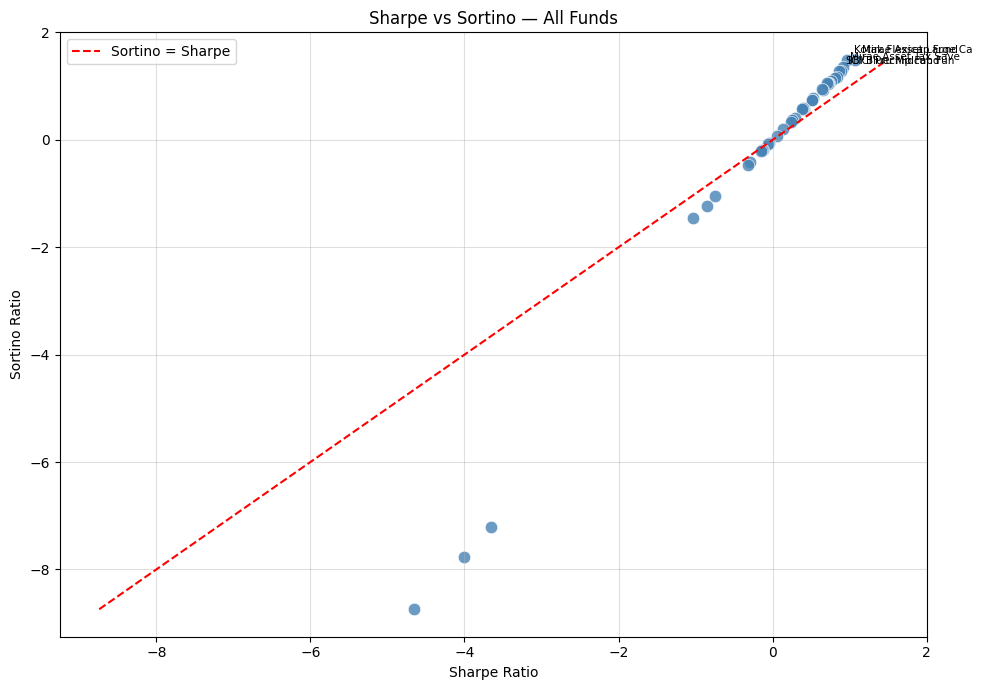

Chart saved: sharpe_vs_sortino.png


In [10]:
combined = sharpe_df[['amfi_code', 'scheme_name', 'sharpe_ratio']].merge(
    sortino_df[['amfi_code', 'sortino_ratio']], on='amfi_code'
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(combined['sharpe_ratio'], combined['sortino_ratio'],
           color='steelblue', s=80, alpha=0.8, edgecolors='white', linewidths=0.5)

mn = min(combined['sharpe_ratio'].min(), combined['sortino_ratio'].min())
mx = max(combined['sharpe_ratio'].max(), combined['sortino_ratio'].max())
ax.plot([mn, mx], [mn, mx], color='red', linestyle='--', linewidth=1.5, label='Sortino = Sharpe')

for _, row in combined.nlargest(5, 'sortino_ratio').iterrows():
    ax.annotate(row['scheme_name'][:20], (row['sharpe_ratio'], row['sortino_ratio']),
                fontsize=7.5, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Sortino Ratio')
ax.set_title('Sharpe vs Sortino — All Funds')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'sharpe_vs_sortino.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: sharpe_vs_sortino.png')

---
## Task 5 — Alpha and Beta

We run a simple linear regression:
`Fund Return = Alpha + Beta × Nifty100 Return`

- **Beta** = how much the fund moves when the market moves (1 = same as market)
- **Alpha** = extra return the fund earns beyond the market (positive = good manager)
- Alpha is annualised by multiplying by 252 (trading days)

In [11]:
nifty100 = bench_df[bench_df['index_name'] == 'NIFTY100'].copy().sort_values('date')
nifty100['bm_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna(subset=['bm_return'])[['date', 'bm_return']]

ab_list = []

for code, group in ret_df.groupby('amfi_code'):
    fund_ret = group[['date', 'daily_return', 'scheme_name', 'category']].dropna()
    merged   = fund_ret.merge(nifty100, on='date', how='inner')

    if len(merged) < 60:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged['bm_return'].values,
        merged['daily_return'].values
    )

    ab_list.append({
        'amfi_code'   : code,
        'scheme_name' : merged['scheme_name'].iloc[0],
        'category'    : merged['category'].iloc[0],
        'alpha_annual': intercept * 252,
        'beta'        : slope,
        'r_squared'   : round(r_value ** 2, 4),
        'p_value'     : round(p_value, 6),
        'n_obs'       : len(merged),
    })

ab_df = pd.DataFrame(ab_list).sort_values('alpha_annual', ascending=False).reset_index(drop=True)
ab_df['alpha_rank'] = range(1, len(ab_df) + 1)

ab_df.to_csv(os.path.join(REPORTS, 'alpha_beta.csv'), index=False)
print('Saved: alpha_beta.csv')
print()
print('Top 10 Funds by Alpha:')
print()
for _, row in ab_df.head(10).iterrows():
    sign = '+' if row['alpha_annual'] > 0 else ''
    print(f"  Rank {int(row['alpha_rank']):<3}  {row['scheme_name'][:45]:<45}  Alpha: {sign}{row['alpha_annual']*100:.2f}%  Beta: {row['beta']:.3f}")

Saved: alpha_beta.csv

Top 10 Funds by Alpha:

  Rank 1    SBI Small Cap Fund - Regular Plan - Growth     Alpha: +30.34%  Beta: -0.023
  Rank 2    DSP Small Cap Fund - Regular - Growth          Alpha: +30.06%  Beta: 0.011
  Rank 3    ICICI Pru Midcap Fund - Regular - Growth       Alpha: +29.26%  Beta: 0.001
  Rank 4    Mirae Asset Tax Saver Fund - Regular - Growth  Alpha: +28.27%  Beta: 0.018
  Rank 5    Kotak Flexicap Fund - Regular - Growth         Alpha: +27.33%  Beta: -0.023
  Rank 6    HDFC Mid-Cap Opportunities Fund - Regular - G  Alpha: +27.20%  Beta: 0.005
  Rank 7    Mirae Asset Large Cap Fund - Regular - Growth  Alpha: +26.98%  Beta: 0.024
  Rank 8    DSP Midcap Fund - Regular - Growth             Alpha: +26.60%  Beta: -0.003
  Rank 9    Axis Midcap Fund - Regular - Growth            Alpha: +26.08%  Beta: -0.066
  Rank 10   SBI Bluechip Fund - Regular Plan - Growth      Alpha: +23.20%  Beta: -0.032


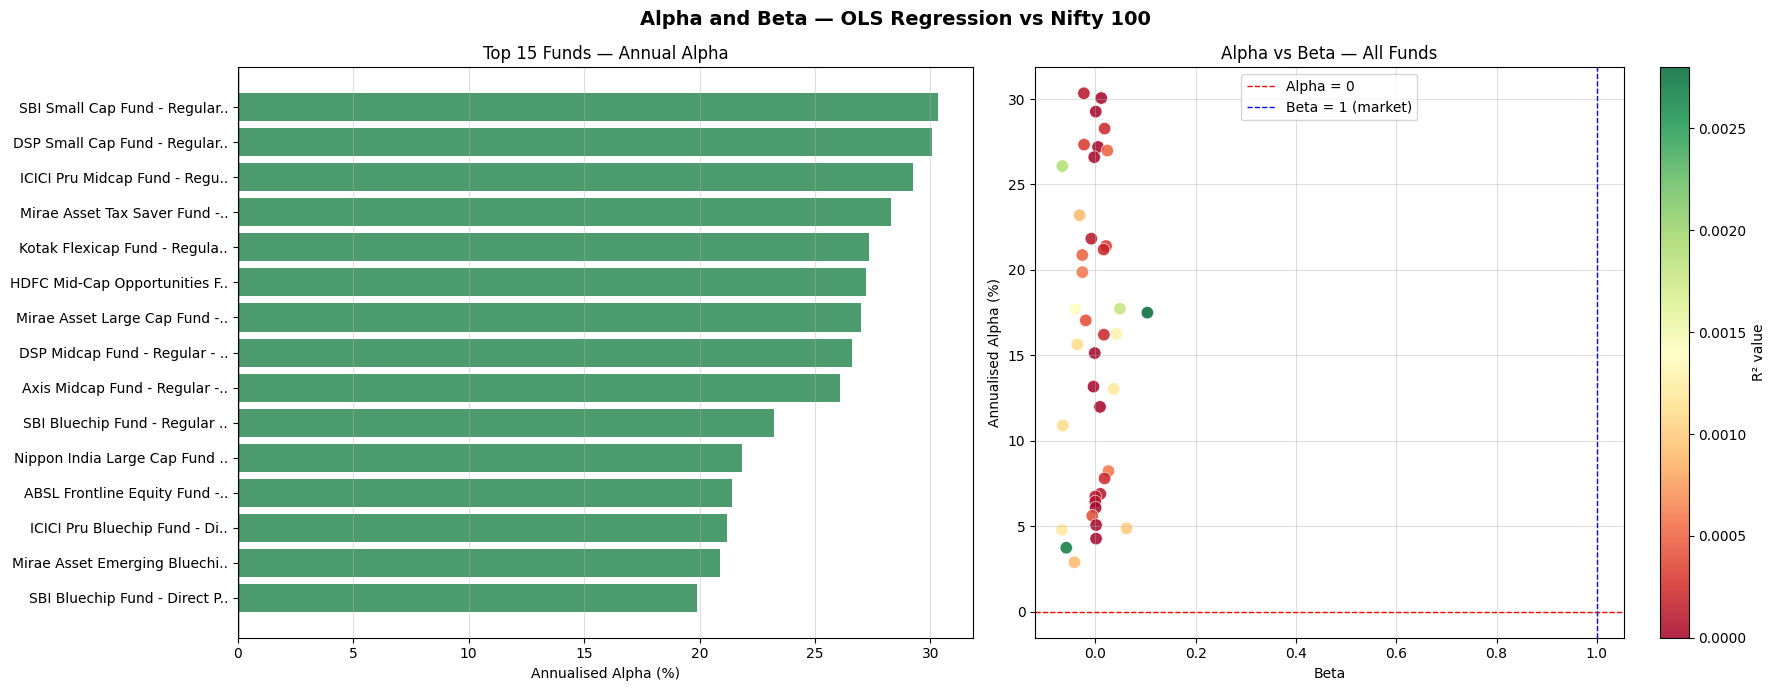

Chart saved: alpha_beta_analysis.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Alpha and Beta — OLS Regression vs Nifty 100', fontsize=14, fontweight='bold')

top15a = ab_df.head(15)
names  = [n[:28] + '..' if len(n) > 28 else n for n in top15a['scheme_name']]
avals  = top15a['alpha_annual'] * 100
acols  = ['seagreen' if v > 0 else 'tomato' for v in avals]

axes[0].barh(names[::-1], avals.values[::-1], color=acols[::-1], alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Annualised Alpha (%)')
axes[0].set_title('Top 15 Funds — Annual Alpha')
axes[0].grid(axis='x', alpha=0.4)

sc = axes[1].scatter(ab_df['beta'], ab_df['alpha_annual'] * 100,
                     c=ab_df['r_squared'], cmap='RdYlGn', s=80,
                     alpha=0.85, edgecolors='white', linewidths=0.5)
plt.colorbar(sc, ax=axes[1], label='R² value')
axes[1].axhline(0, color='red',  linestyle='--', linewidth=1, label='Alpha = 0')
axes[1].axvline(1, color='blue', linestyle='--', linewidth=1, label='Beta = 1 (market)')
axes[1].set_xlabel('Beta')
axes[1].set_ylabel('Annualised Alpha (%)')
axes[1].set_title('Alpha vs Beta — All Funds')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'alpha_beta_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: alpha_beta_analysis.png')

---
## Task 6 — Maximum Drawdown

**Formula:** `Max Drawdown = min(NAV / highest NAV so far − 1)`

It shows the worst loss a fund suffered from its peak value.
For example, −25% means the fund dropped 25% from its all-time high before recovering.

In [13]:
def get_max_drawdown(nav_series, date_series):
    nav_series  = nav_series.reset_index(drop=True)
    date_series = date_series.reset_index(drop=True)

    running_max = nav_series.cummax()
    drawdown    = nav_series / running_max - 1
    max_dd      = drawdown.min()

    trough_pos  = drawdown.idxmin()
    trough_date = date_series.iloc[trough_pos]

    peak_pos    = nav_series.iloc[:trough_pos + 1].idxmax()
    peak_date   = date_series.iloc[peak_pos]
    peak_nav    = nav_series.iloc[peak_pos]

    recovery_date = None
    after_trough  = nav_series.iloc[trough_pos:]
    recovered     = after_trough[after_trough >= peak_nav]
    if len(recovered) > 0:
        recovery_date = date_series.iloc[recovered.index[0]]

    return max_dd, peak_date, trough_date, recovery_date, drawdown


mdd_list      = []
drawdown_dict = {}

for code, group in nav_df.groupby('amfi_code'):
    group = group.sort_values('date').reset_index(drop=True)

    max_dd, peak_date, trough_date, recovery_date, dd_series = get_max_drawdown(
        group['nav'], group['date']
    )

    drawdown_dict[code] = {
        'dates'   : group['date'].values,
        'drawdown': dd_series.values,
        'name'    : group['scheme_name'].iloc[0],
    }

    duration = (trough_date - peak_date).days if pd.notna(peak_date) and pd.notna(trough_date) else 0

    mdd_list.append({
        'amfi_code'    : code,
        'scheme_name'  : group['scheme_name'].iloc[0],
        'category'     : group['category'].iloc[0],
        'max_drawdown' : max_dd,
        'peak_date'    : peak_date,
        'trough_date'  : trough_date,
        'recovery_date': recovery_date,
        'duration_days': duration,
    })

mdd_df = pd.DataFrame(mdd_list).sort_values('max_drawdown').reset_index(drop=True)
mdd_df['mdd_rank'] = range(1, len(mdd_df) + 1)

print('Worst 10 Drawdowns:')
print()
for _, row in mdd_df.head(10).iterrows():
    peak   = row['peak_date'].strftime('%Y-%m-%d')   if pd.notna(row['peak_date'])   else 'N/A'
    trough = row['trough_date'].strftime('%Y-%m-%d') if pd.notna(row['trough_date']) else 'N/A'
    rec    = row['recovery_date'].strftime('%Y-%m-%d') if pd.notna(row['recovery_date']) else 'Not recovered'
    print(f"  Rank {int(row['mdd_rank']):<3}  {row['scheme_name'][:38]:<38}  MDD: {row['max_drawdown']*100:.1f}%  Peak: {peak}  Trough: {trough}")

Worst 10 Drawdowns:

  Rank 1    SBI Small Cap Fund - Direct Plan - Gro  MDD: -52.6%  Peak: 2023-01-17  Trough: 2025-10-28
  Rank 2    Axis Small Cap Fund - Regular - Growth  MDD: -51.7%  Peak: 2025-05-22  Trough: 2026-05-11
  Rank 3    ABSL Small Cap Fund - Regular - Growth  MDD: -35.4%  Peak: 2024-11-21  Trough: 2026-05-11
  Rank 4    DSP Small Cap Fund - Regular - Growth   MDD: -31.2%  Peak: 2024-05-03  Trough: 2025-01-03
  Rank 5    SBI Small Cap Fund - Regular Plan - Gr  MDD: -28.7%  Peak: 2024-08-28  Trough: 2025-05-14
  Rank 6    UTI Mid Cap Fund - Regular - Growth     MDD: -28.0%  Peak: 2025-01-07  Trough: 2026-04-27
  Rank 7    HDFC Top 100 Fund - Regular Plan - Gro  MDD: -24.7%  Peak: 2022-03-30  Trough: 2022-09-15
  Rank 8    Kotak Emerging Equity Fund - Regular -  MDD: -24.0%  Peak: 2023-11-09  Trough: 2024-10-17
  Rank 9    Nippon India Small Cap Fund - Regular   MDD: -23.3%  Peak: 2025-04-09  Trough: 2026-02-20
  Rank 10   Axis Bluechip Fund - Direct - Growth    MDD: -21.

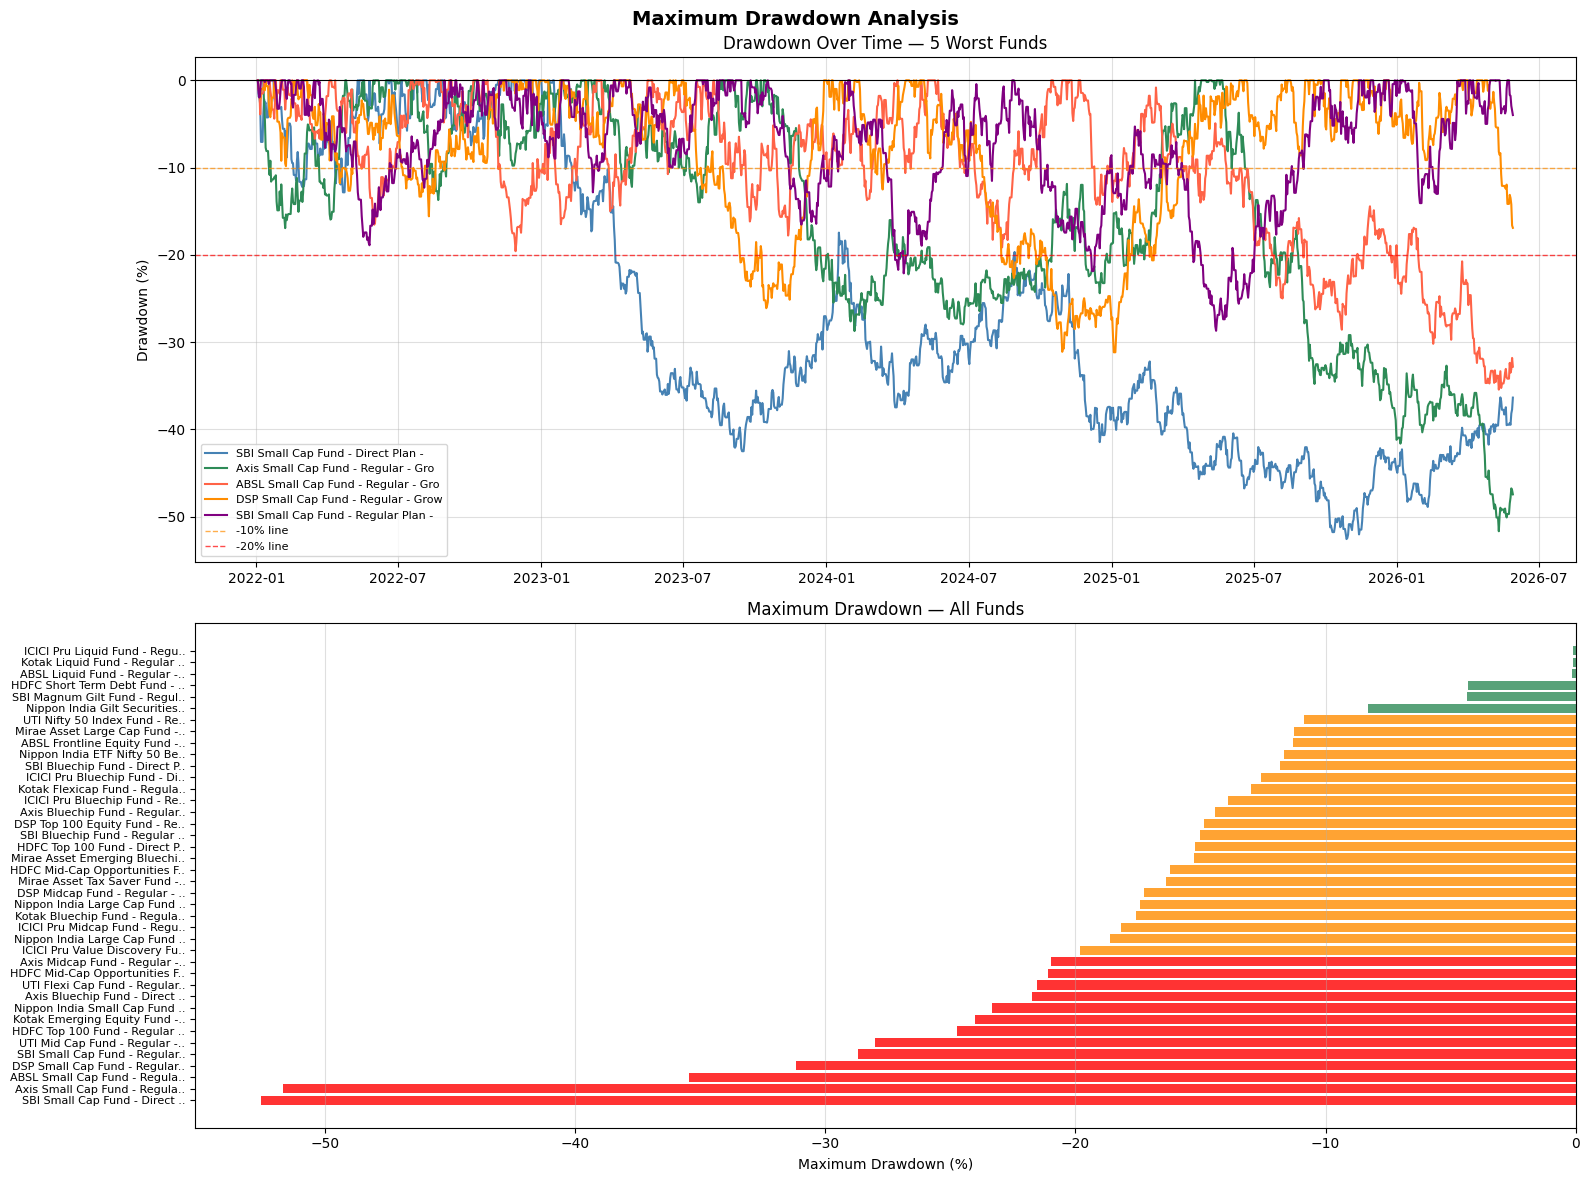

Chart saved: maximum_drawdown.png


In [14]:
worst5_codes = mdd_df.head(5)['amfi_code'].tolist()
line_colors  = ['steelblue', 'seagreen', 'tomato', 'darkorange', 'purple']

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Maximum Drawdown Analysis', fontsize=14, fontweight='bold')

for i, code in enumerate(worst5_codes):
    d = drawdown_dict[code]
    axes[0].plot(d['dates'], d['drawdown'] * 100, color=line_colors[i],
                 linewidth=1.5, label=d['name'][:35])

axes[0].axhline(0,   color='black',      linewidth=0.8)
axes[0].axhline(-10, color='darkorange', linestyle='--', linewidth=1, alpha=0.7, label='-10% line')
axes[0].axhline(-20, color='red',        linestyle='--', linewidth=1, alpha=0.7, label='-20% line')
axes[0].set_ylabel('Drawdown (%)')
axes[0].set_title('Drawdown Over Time — 5 Worst Funds')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

all_names = [n[:28] + '..' if len(n) > 28 else n for n in mdd_df['scheme_name']]
dd_vals   = mdd_df['max_drawdown'].values * 100
bar_cols  = ['red' if v < -20 else 'darkorange' if v < -10 else 'seagreen' for v in dd_vals]

axes[1].barh(range(len(mdd_df)), dd_vals, color=bar_cols, alpha=0.8)
axes[1].set_yticks(range(len(mdd_df)))
axes[1].set_yticklabels(all_names, fontsize=8)
axes[1].set_xlabel('Maximum Drawdown (%)')
axes[1].set_title('Maximum Drawdown — All Funds')
axes[1].grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'maximum_drawdown.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: maximum_drawdown.png')

---
## Task 7 — Fund Scorecard (0 to 100)

Each fund gets a score out of 100 based on 5 criteria:

| Metric | Weight | What it means |
|---|---|---|
| 3-Year CAGR | 30% | Higher growth = better |
| Sharpe Ratio | 25% | Higher risk-adjusted return = better |
| Alpha | 20% | Manager skill (higher = better) |
| Expense Ratio | 15% | Lower fees = better |
| Max Drawdown | 10% | Smaller loss from peak = better |

In [15]:
scorecard = cagr_df[['amfi_code', 'scheme_name', 'category', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].copy()

scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio', 'annual_return', 'annual_std']], on='amfi_code', how='left')
scorecard = scorecard.merge(sortino_df[['amfi_code', 'sortino_ratio']],                              on='amfi_code', how='left')
scorecard = scorecard.merge(ab_df[['amfi_code', 'alpha_annual', 'beta', 'r_squared']],               on='amfi_code', how='left')
scorecard = scorecard.merge(mdd_df[['amfi_code', 'max_drawdown', 'peak_date', 'trough_date']],       on='amfi_code', how='left')
scorecard = scorecard.merge(fund_df[['amfi_code', 'expense_ratio_pct']],                             on='amfi_code', how='left')

scorecard = scorecard.dropna(subset=['cagr_3yr', 'sharpe_ratio', 'alpha_annual', 'expense_ratio_pct', 'max_drawdown'])
scorecard = scorecard.reset_index(drop=True)
n = len(scorecard)
print(f'Funds in scorecard: {n}')

def pct_rank(series, higher_is_better=True):
    ranked = series.rank(ascending=higher_is_better, method='min')
    if n <= 1:
        return ranked * 0 + 50
    return (ranked - 1) / (n - 1) * 100

scorecard['score_3yr']     = pct_rank(scorecard['cagr_3yr'],          higher_is_better=True)
scorecard['score_sharpe']  = pct_rank(scorecard['sharpe_ratio'],      higher_is_better=True)
scorecard['score_alpha']   = pct_rank(scorecard['alpha_annual'],      higher_is_better=True)
scorecard['score_expense'] = pct_rank(scorecard['expense_ratio_pct'], higher_is_better=False)
scorecard['score_mdd']     = pct_rank(scorecard['max_drawdown'],      higher_is_better=False)

scorecard['composite_score'] = (
    0.30 * scorecard['score_3yr']     +
    0.25 * scorecard['score_sharpe']  +
    0.20 * scorecard['score_alpha']   +
    0.15 * scorecard['score_expense'] +
    0.10 * scorecard['score_mdd']
).round(2)

scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard['overall_rank'] = range(1, len(scorecard) + 1)

save_cols = [
    'amfi_code', 'scheme_name', 'category', 'overall_rank', 'composite_score',
    'cagr_1yr', 'cagr_3yr', 'cagr_5yr', 'sharpe_ratio', 'sortino_ratio',
    'alpha_annual', 'beta', 'r_squared', 'max_drawdown', 'expense_ratio_pct',
    'score_3yr', 'score_sharpe', 'score_alpha', 'score_expense', 'score_mdd'
]
scorecard[save_cols].to_csv(os.path.join(REPORTS, 'fund_scorecard.csv'), index=False)
print('Saved: fund_scorecard.csv')
print()
print('Top 10 Funds by Composite Score:')
print()
for _, row in scorecard.head(10).iterrows():
    print(f"  Rank {int(row['overall_rank']):<3}  {row['scheme_name'][:48]:<48}  Score: {row['composite_score']:.1f}")

Funds in scorecard: 40
Saved: fund_scorecard.csv

Top 10 Funds by Composite Score:

  Rank 1    ICICI Pru Midcap Fund - Regular - Growth          Score: 84.7
  Rank 2    Axis Midcap Fund - Regular - Growth               Score: 81.2
  Rank 3    HDFC Mid-Cap Opportunities Fund - Regular - Grow  Score: 79.6
  Rank 4    Mirae Asset Large Cap Fund - Regular - Growth     Score: 79.5
  Rank 5    Kotak Flexicap Fund - Regular - Growth            Score: 76.9
  Rank 6    SBI Small Cap Fund - Regular Plan - Growth        Score: 75.1
  Rank 7    DSP Small Cap Fund - Regular - Growth             Score: 74.7
  Rank 8    ICICI Pru Bluechip Fund - Direct - Growth         Score: 74.5
  Rank 9    Mirae Asset Tax Saver Fund - Regular - Growth     Score: 73.8
  Rank 10   SBI Bluechip Fund - Regular Plan - Growth         Score: 71.5


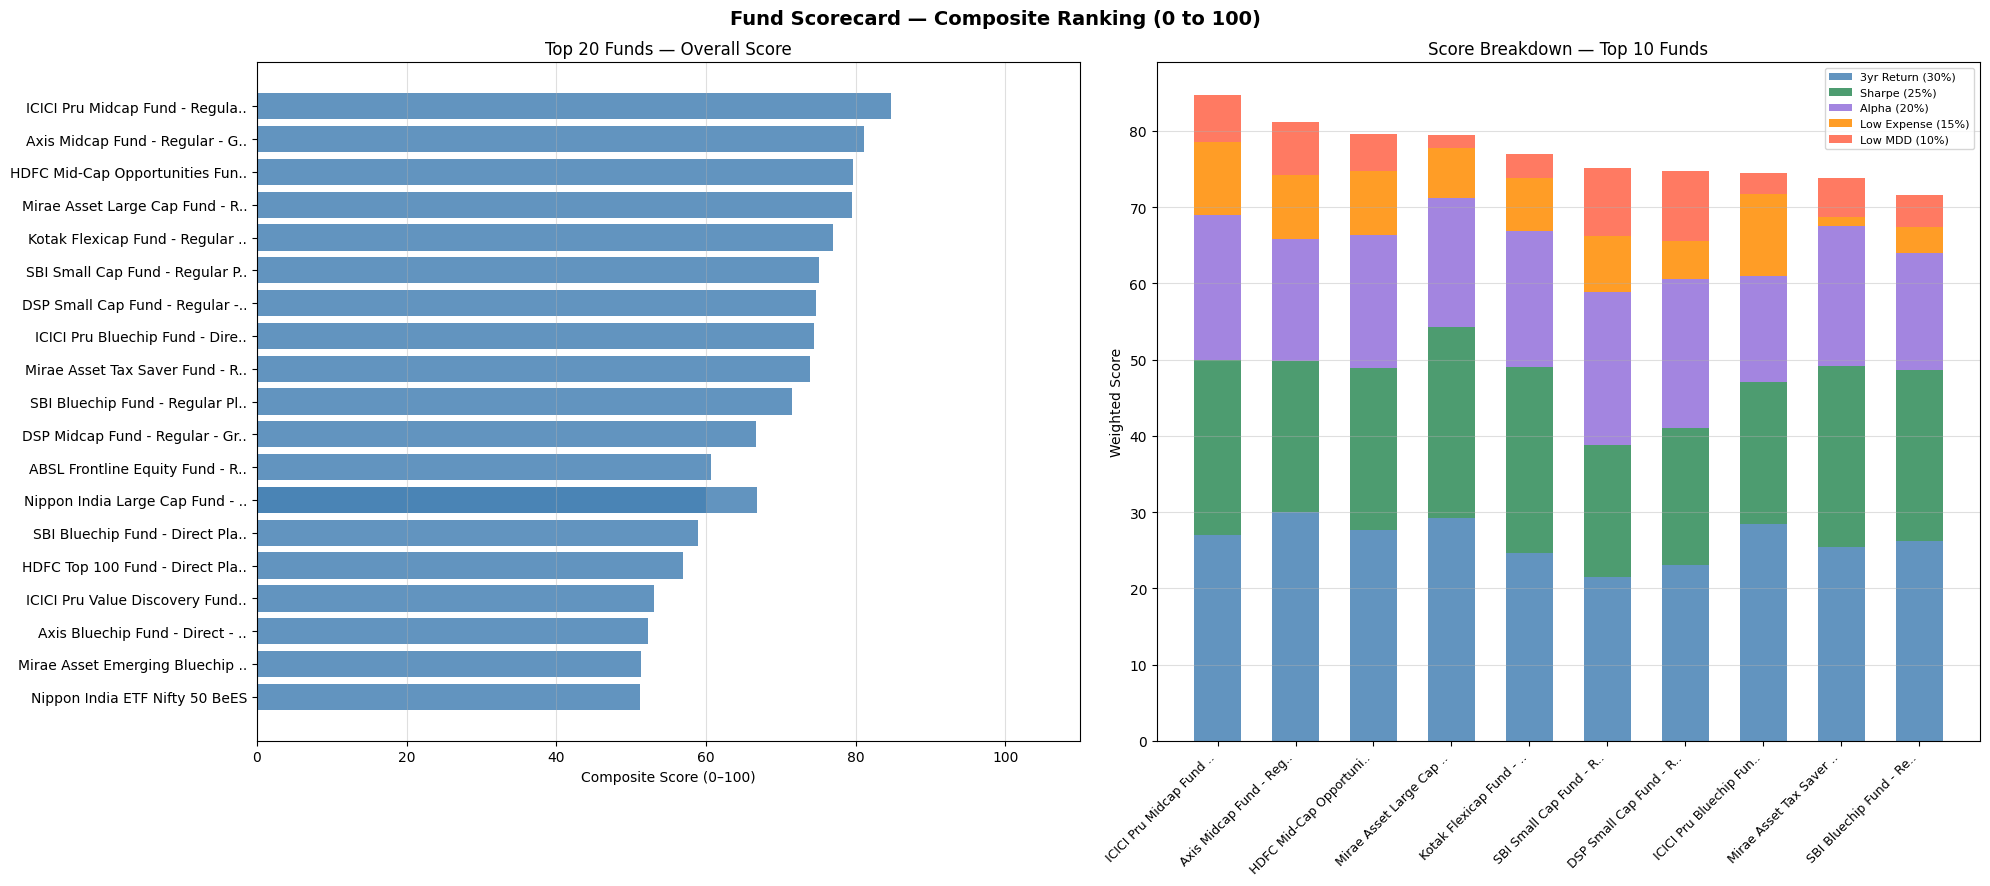

Chart saved: fund_scorecard_chart.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Fund Scorecard — Composite Ranking (0 to 100)', fontsize=14, fontweight='bold')

top20 = scorecard.head(20).copy()
names = [n[:30] + '..' if len(n) > 30 else n for n in top20['scheme_name']]
axes[0].barh(names[::-1], top20['composite_score'].values[::-1], color='steelblue', alpha=0.85)
axes[0].set_xlabel('Composite Score (0–100)')
axes[0].set_title('Top 20 Funds — Overall Score')
axes[0].set_xlim(0, 110)
axes[0].grid(axis='x', alpha=0.4)

top10 = scorecard.head(10).copy()
names10 = [n[:22] + '..' if len(n) > 22 else n for n in top10['scheme_name']]
x = np.arange(len(top10))

components = {
    '3yr Return (30%)' : top10['score_3yr'].values * 0.30,
    'Sharpe (25%)'     : top10['score_sharpe'].values * 0.25,
    'Alpha (20%)'      : top10['score_alpha'].values * 0.20,
    'Low Expense (15%)': top10['score_expense'].values * 0.15,
    'Low MDD (10%)'    : top10['score_mdd'].values * 0.10,
}
stack_colors = ['steelblue', 'seagreen', 'mediumpurple', 'darkorange', 'tomato']
bottom = np.zeros(len(top10))

for (label, vals), color in zip(components.items(), stack_colors):
    axes[1].bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.85, width=0.6)
    bottom += vals

axes[1].set_xticks(x)
axes[1].set_xticklabels(names10, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Weighted Score')
axes[1].set_title('Score Breakdown — Top 10 Funds')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'fund_scorecard_chart.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: fund_scorecard_chart.png')

---
## Task 8 — Benchmark Comparison + Tracking Error

We compare **Top 5 funds vs Nifty 50 and Nifty 100** over 3 years.

All values are set to **₹100 at the start** so comparison is fair.

**Tracking Error** = `std(fund return − benchmark return) × √252`  
Lower tracking error = fund moves more like the benchmark.

In [17]:
end_date   = nav_df['date'].max()
start_date = end_date - pd.DateOffset(years=3)

top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5)['scheme_name'].tolist()

nav_3yr   = nav_df[(nav_df['date'] >= start_date) & (nav_df['date'] <= end_date)].copy()
nifty50   = bench_df[(bench_df['index_name'] == 'NIFTY50')  & (bench_df['date'] >= start_date)].copy().sort_values('date')
nifty100b = bench_df[(bench_df['index_name'] == 'NIFTY100') & (bench_df['date'] >= start_date)].copy().sort_values('date')

nifty50['bm_return']   = nifty50['close_value'].pct_change()
nifty100b['bm_return'] = nifty100b['close_value'].pct_change()

print('3-year window:', start_date.date(), 'to', end_date.date())
print()
print('Top 5 Funds selected:')
for i, (code, name) in enumerate(zip(top5_codes, top5_names), 1):
    score = scorecard[scorecard['amfi_code'] == code]['composite_score'].values[0]
    print(f'  {i}. {name[:55]}  (Score: {score:.1f})')

3-year window: 2023-05-29 to 2026-05-29

Top 5 Funds selected:
  1. ICICI Pru Midcap Fund - Regular - Growth  (Score: 84.7)
  2. Axis Midcap Fund - Regular - Growth  (Score: 81.2)
  3. HDFC Mid-Cap Opportunities Fund - Regular - Growth  (Score: 79.6)
  4. Mirae Asset Large Cap Fund - Regular - Growth  (Score: 79.5)
  5. Kotak Flexicap Fund - Regular - Growth  (Score: 76.9)


In [18]:
te_list = []

for code, name in zip(top5_codes, top5_names):
    grp = nav_3yr[nav_3yr['amfi_code'] == code].sort_values('date').copy()
    grp['daily_return'] = grp['nav'].pct_change()
    grp = grp.dropna(subset=['daily_return'])

    m100 = grp.merge(nifty100b[['date', 'bm_return']], on='date', how='inner')
    m50  = grp.merge(nifty50[['date', 'bm_return']],   on='date', how='inner')

    te100 = (m100['daily_return'] - m100['bm_return']).std() * np.sqrt(252) if len(m100) > 20 else np.nan
    te50  = (m50['daily_return']  - m50['bm_return']).std()  * np.sqrt(252) if len(m50)  > 20 else np.nan

    te_list.append({'amfi_code': code, 'scheme_name': name, 'te_nifty100': te100, 'te_nifty50': te50})

te_df = pd.DataFrame(te_list)
print('Tracking Error — Top 5 Funds:')
print()
for _, row in te_df.iterrows():
    t100 = f"{row['te_nifty100']*100:.2f}%" if pd.notna(row['te_nifty100']) else 'N/A'
    t50  = f"{row['te_nifty50']*100:.2f}%"  if pd.notna(row['te_nifty50'])  else 'N/A'
    print(f"  {row['scheme_name'][:48]:<48}  TE vs N100: {t100}  TE vs N50: {t50}")

Tracking Error — Top 5 Funds:

  ICICI Pru Midcap Fund - Regular - Growth          TE vs N100: 23.27%  TE vs N50: 22.84%
  Axis Midcap Fund - Regular - Growth               TE vs N100: 23.98%  TE vs N50: 23.88%
  HDFC Mid-Cap Opportunities Fund - Regular - Grow  TE vs N100: 22.50%  TE vs N50: 22.82%
  Mirae Asset Large Cap Fund - Regular - Growth     TE vs N100: 18.80%  TE vs N50: 19.19%
  Kotak Flexicap Fund - Regular - Growth            TE vs N100: 20.65%  TE vs N50: 20.51%


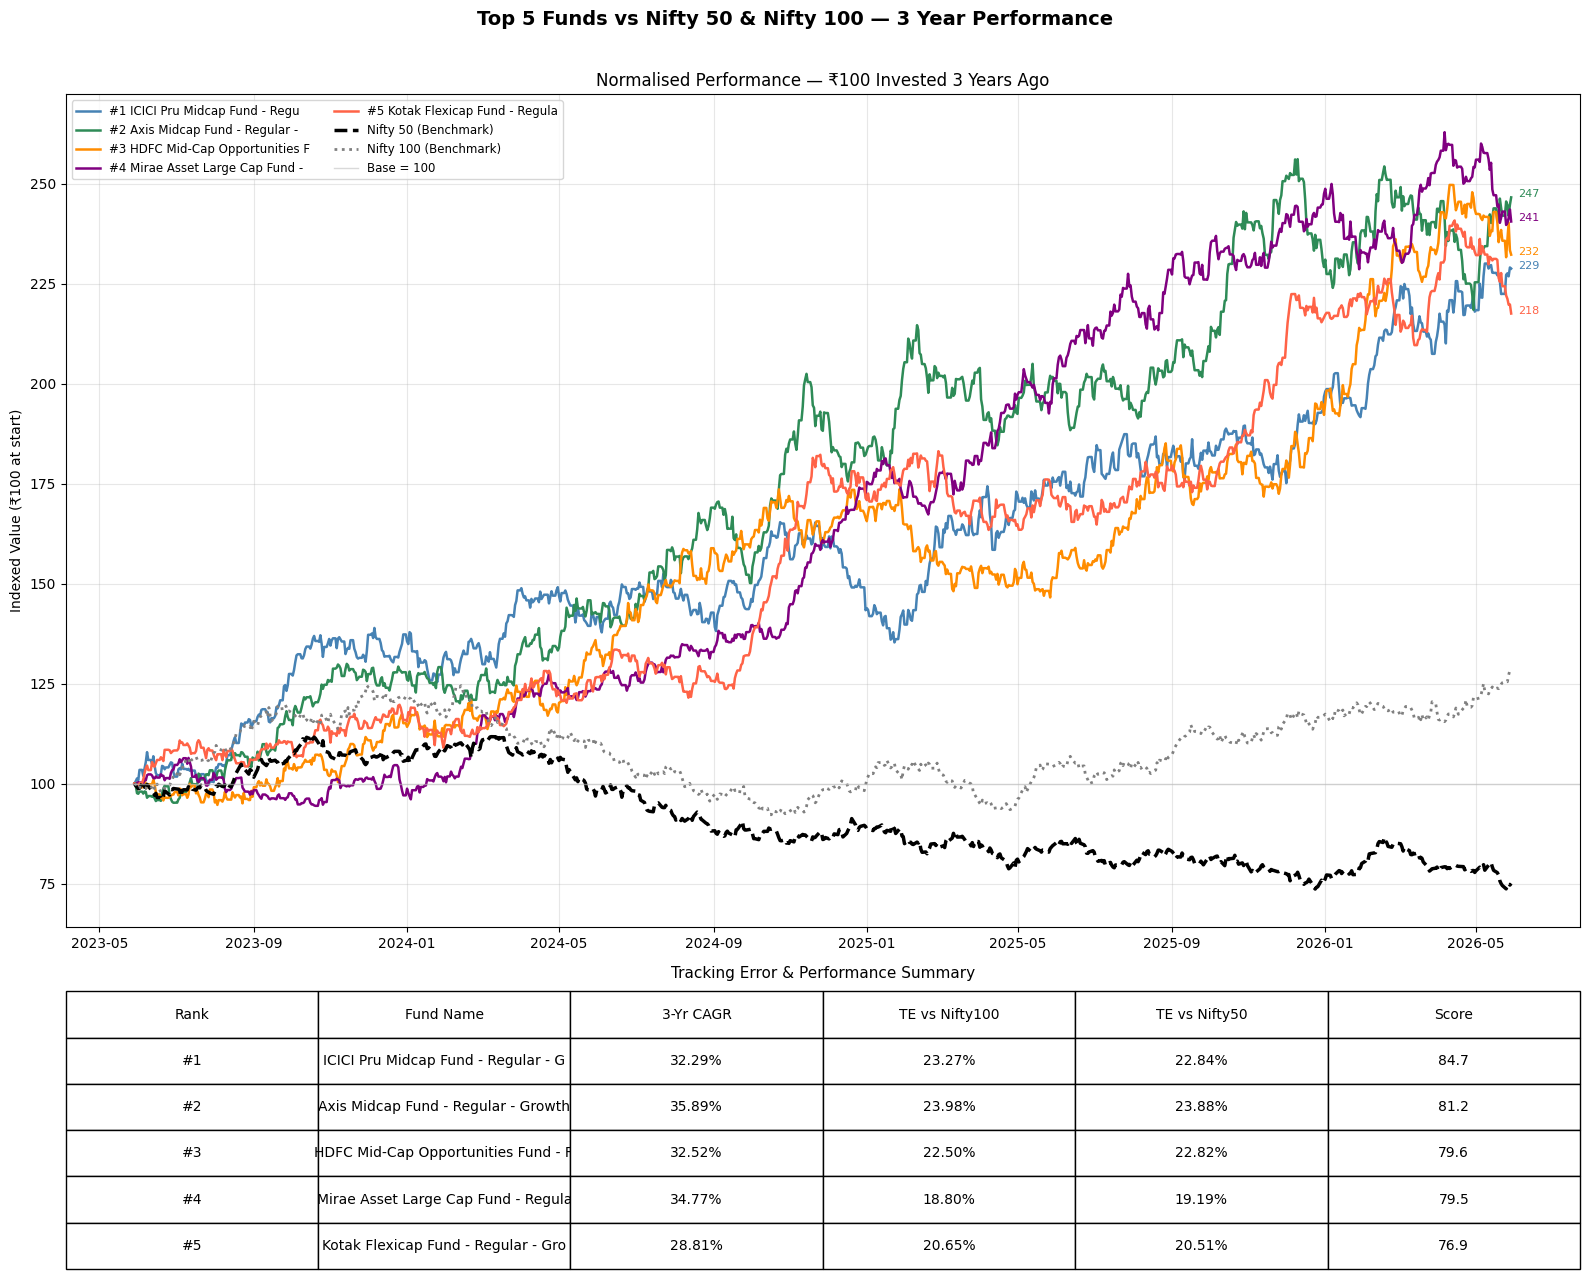

Saved: benchmark_comparison.png


In [19]:
def normalise(series):
    series = series.reset_index(drop=True)
    return series / series.iloc[0] * 100


fund_colors = ['steelblue', 'seagreen', 'darkorange', 'purple', 'tomato']

fig, axes = plt.subplots(2, 1, figsize=(16, 13), gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance',
             fontsize=14, fontweight='bold')

for i, (code, name) in enumerate(zip(top5_codes, top5_names)):
    grp = nav_3yr[nav_3yr['amfi_code'] == code].sort_values('date').reset_index(drop=True)
    if len(grp) < 2:
        continue
    norm = normalise(grp['nav'])
    axes[0].plot(grp['date'].values, norm.values, color=fund_colors[i],
                 linewidth=1.8, label=f'#{i+1} ' + name[:28])
    axes[0].annotate(f'{norm.values[-1]:.0f}',
                     xy=(grp['date'].values[-1], norm.values[-1]),
                     fontsize=8, xytext=(5, 0), textcoords='offset points',
                     color=fund_colors[i])

nifty50_reset   = nifty50.reset_index(drop=True)
nifty100b_reset = nifty100b.reset_index(drop=True)

axes[0].plot(nifty50_reset['date'].values,   normalise(nifty50_reset['close_value']).values,
             color='black', linewidth=2.5, linestyle='--', label='Nifty 50 (Benchmark)')
axes[0].plot(nifty100b_reset['date'].values, normalise(nifty100b_reset['close_value']).values,
             color='gray',  linewidth=2.0, linestyle=':',  label='Nifty 100 (Benchmark)')

axes[0].axhline(100, color='silver', linewidth=1, linestyle='-', alpha=0.6, label='Base = 100')
axes[0].set_ylabel('Indexed Value (₹100 at start)')
axes[0].set_title('Normalised Performance — ₹100 Invested 3 Years Ago')
axes[0].legend(fontsize=8.5, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].axis('off')
table_data = []
for i, (_, row) in enumerate(te_df.iterrows()):
    sc_row = scorecard[scorecard['amfi_code'] == row['amfi_code']]
    cagr   = sc_row['cagr_3yr'].values[0]        if len(sc_row) > 0 else np.nan
    score  = sc_row['composite_score'].values[0]  if len(sc_row) > 0 else np.nan
    t100   = f"{row['te_nifty100']*100:.2f}%" if pd.notna(row['te_nifty100']) else 'N/A'
    t50    = f"{row['te_nifty50']*100:.2f}%"  if pd.notna(row['te_nifty50'])  else 'N/A'
    table_data.append([
        f'#{i+1}',
        row['scheme_name'][:35],
        f"{cagr*100:.2f}%" if pd.notna(cagr) else 'N/A',
        t100, t50,
        f"{score:.1f}"      if pd.notna(score) else 'N/A',
    ])

table = axes[1].table(
    cellText=table_data,
    colLabels=['Rank', 'Fund Name', '3-Yr CAGR', 'TE vs Nifty100', 'TE vs Nifty50', 'Score'],
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title('Tracking Error & Performance Summary', fontsize=11, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(REPORTS, 'benchmark_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison.png')

---
## Final — Check All Deliverables

In [20]:
print('=' * 58)
print('  DAY 4 DELIVERABLES CHECK')
print('=' * 58)

files = [
    ('fund_scorecard.csv',             os.path.join(REPORTS, 'fund_scorecard.csv')),
    ('alpha_beta.csv',                 os.path.join(REPORTS, 'alpha_beta.csv')),
    ('benchmark_comparison.png',       os.path.join(REPORTS, 'benchmark_comparison.png')),
    ('daily_return_distribution.png',  os.path.join(REPORTS, 'daily_return_distribution.png')),
    ('cagr_comparison.png',            os.path.join(REPORTS, 'cagr_comparison.png')),
    ('sharpe_ratio_ranking.png',       os.path.join(REPORTS, 'sharpe_ratio_ranking.png')),
    ('sharpe_vs_sortino.png',          os.path.join(REPORTS, 'sharpe_vs_sortino.png')),
    ('alpha_beta_analysis.png',        os.path.join(REPORTS, 'alpha_beta_analysis.png')),
    ('maximum_drawdown.png',           os.path.join(REPORTS, 'maximum_drawdown.png')),
    ('fund_scorecard_chart.png',       os.path.join(REPORTS, 'fund_scorecard_chart.png')),
]

for name, path in files:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f'  OK    {name:<38}  {size:.0f} KB')
    else:
        print(f'  MISS  {name}')

print('=' * 58)
print()
print('Day 4 Complete!')
print('Next: git add . && git commit -m "Day 4: Performance Analytics complete"')

  DAY 4 DELIVERABLES CHECK
  OK    fund_scorecard.csv                      12 KB
  OK    alpha_beta.csv                          5 KB
  OK    benchmark_comparison.png                520 KB
  OK    daily_return_distribution.png           92 KB
  OK    cagr_comparison.png                     85 KB
  OK    sharpe_ratio_ranking.png                97 KB
  OK    sharpe_vs_sortino.png                   50 KB
  OK    alpha_beta_analysis.png                 126 KB
  OK    maximum_drawdown.png                    425 KB
  OK    fund_scorecard_chart.png                168 KB

Day 4 Complete!
Next: git add . && git commit -m "Day 4: Performance Analytics complete"
